<a href="https://colab.research.google.com/github/rah-ds/Cloud-Autoscaling-using-RL/blob/bmcgregor%2Fsimulator-refactor/DQN_Compare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Download Files from Repo

In [1]:
import os


GITHUB_USER = "rah-ds"
REPO_NAME   = "Cloud-Autoscaling-using-RL"
BRANCH      = "bmcgregor/simulator-refactor"  # or "main" or another branch

# Base raw URL for GitHub
BASE_RAW_URL = f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}"

# Map of local filename -> path inside the repo

PY_FILES = {
    # Environment
    "autoscaling_env.py": "scripts/autoscaling_env.py",

    # DQN utilities and agents
    "DQN_Utils.py": "scripts/DQN_Utils.py",
    "DQN_Agent.py": "scripts/DQN_Agent.py",
    "Double_DQN_Agent.py": "scripts/Double_DQN_Agent.py",

}

print("Downloading Python files from GitHub...")
# Use a cross-platform Python downloader: try requests, fall back to urllib
try:
    import requests  # type: ignore
except Exception:
    requests = None

from urllib.request import urlopen, Request


# Directly set the download directory to /content/
DOWNLOAD_DIR = "/content/"
os.makedirs(DOWNLOAD_DIR, exist_ok=True) # Ensure the directory exists
print("Writing downloads to:", DOWNLOAD_DIR)

for local_name, repo_path in PY_FILES.items():
    url = f"{BASE_RAW_URL}/{repo_path}"
    print(f"  -> {local_name}  from  {url}")
    content = None
    if requests is not None:
        try:
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            content = resp.content
        except Exception as e:
            print(f"requests download failed: {e}; falling back to urllib")
            content = None
    if content is None:
        req = Request(url, headers={"User-Agent": "python-urllib/3"})
        try:
            with urlopen(req, timeout=30) as r:
                content = r.read()
        except Exception as e:
            print(f"Failed to download {url}: {e}")
            continue
    target_path = os.path.join(DOWNLOAD_DIR, local_name)
    try:
        with open(target_path, "wb") as f:
            f.write(content)
    except Exception as e:
        print(f"Failed to write {target_path}: {e}")

print("Done. Files in download dir:", os.listdir(DOWNLOAD_DIR))

Writing downloads to: /content/
  -> autoscaling_env.py  from  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/bmcgregor/simulator-refactor/scripts/autoscaling_env.py
  -> DQN_Utils.py  from  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/bmcgregor/simulator-refactor/scripts/DQN_Utils.py
  -> DQN_Agent.py  from  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/bmcgregor/simulator-refactor/scripts/DQN_Agent.py
  -> Double_DQN_Agent.py  from  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/bmcgregor/simulator-refactor/scripts/Double_DQN_Agent.py
Done. Files in download dir: ['.config', 'autoscaling_env.py', 'DQN_Utils.py', 'Double_DQN_Agent.py', 'DQN_Agent.py', 'sample_data']


#Setup: Imports and mount Google Drive

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# modules
from DQN_Agent import DQNAgent
from Double_DQN_Agent import DoubleDQNAgent
from DQN_Utils import evaluate_agent

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Mounted at /content/drive
Using device: cpu


#Load the trained models

In [3]:
# Folder in your Google Drive where you saved the model weights
MODEL_DIR = "/content/drive/MyDrive/RL_Checkpoints/"

DQN_CHECKPOINT_PATH = os.path.join(MODEL_DIR, "dqn_checkpoint.pth")
DOUBLE_DQN_CHECKPOINT_PATH = os.path.join(MODEL_DIR, "double_dqn_checkpoint.pth")
DUELING_DQN_CHECKPOINT_PATH = os.path.join(MODEL_DIR, "dueling_dqn_checkpoint.pth")

for p in [DQN_CHECKPOINT_PATH, DOUBLE_DQN_CHECKPOINT_PATH, DUELING_DQN_CHECKPOINT_PATH]:
    print(p, "exists?", os.path.exists(p))


/content/drive/MyDrive/RL_Checkpoints/dqn_checkpoint.pth exists? True
/content/drive/MyDrive/RL_Checkpoints/double_dqn_checkpoint.pth exists? True
/content/drive/MyDrive/RL_Checkpoints/dueling_dqn_checkpoint.pth exists? True


#Define the final evaluation environment

In [5]:
import pandas as pd
from autoscaling_env import AutoScalingEnvConfig, AutoScalingEnv

# Load df_usage
df_usage = pd.read_csv('/content/drive/MyDrive/df_usage.csv')

# Final environment configuration for comparison
final_config = AutoScalingEnvConfig(
    initial_capacity=10,
    target_utilization=0.6,
    sla_threshold=0.8,
    cost_per_machine_per_minute=0.002,
    min_capacity=1,
    max_capacity=12,
    cooldown_period=2,
    demand_scale=1500.0,
    cost_weight=1.0,
    util_weight=3.0,
    sla_weight=15.0,
)

env = AutoScalingEnv(df_usage, config=final_config)

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)


Observation space: Box([0. 1.], [inf 12.], (2,), float32)
Action space: Discrete(3)


#Recreate agents and load weights

In [6]:
from DQN_Agent import DQNAgent
from Double_DQN_Agent import DoubleDQNAgent

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

obs_shape = env.observation_space.shape
n_actions = env.action_space.n

# 1. Vanilla DQN
agent_dqn = DQNAgent(
    observation_space_shape=obs_shape,
    action_space_size=n_actions,
    device=device,
    seed=0
)
agent_dqn.qnetwork_local.load_state_dict(
    torch.load(DQN_CHECKPOINT_PATH, map_location=device)
)
agent_dqn.qnetwork_target.load_state_dict(agent_dqn.qnetwork_local.state_dict())
agent_dqn.qnetwork_local.to(device).eval()

# 2. Double DQN (standard network)
agent_double = DoubleDQNAgent(
    observation_space_shape=obs_shape,
    action_space_size=n_actions,
    device=device,
    seed=0
)
agent_double.qnetwork_local.load_state_dict(
    torch.load(DOUBLE_DQN_CHECKPOINT_PATH, map_location=device)
)
agent_double.qnetwork_target.load_state_dict(agent_double.qnetwork_local.state_dict())
agent_double.qnetwork_local.to(device).eval()

# 3. "Dueling Double DQN" – SAME CLASS, different trained weights
agent_dueling = DoubleDQNAgent(
    observation_space_shape=obs_shape,
    action_space_size=n_actions,
    device=device,
    seed=0
)
agent_dueling.qnetwork_local.load_state_dict(
    torch.load(DUELING_DQN_CHECKPOINT_PATH, map_location=device)
)
agent_dueling.qnetwork_target.load_state_dict(agent_dueling.qnetwork_local.state_dict())
agent_dueling.qnetwork_local.to(device).eval()

print("Loaded: DQN, Double DQN, and Dueling Double DQN (via DoubleDQNAgent).")


Using device: cpu
Loaded: DQN, Double DQN, and Dueling Double DQN (via DoubleDQNAgent).


#Evalute all three agents on the same test setting

In [7]:
num_eval_episodes = 10
max_steps_per_episode = 1000

dqn_scores, dqn_df = evaluate_agent(
    agent_dqn,
    env,
    num_eval_episodes,
    max_steps_per_episode,
    use_random_windows = True
)

double_scores, double_df = evaluate_agent(
    agent_double,
    env,
    num_eval_episodes,
    max_steps_per_episode,
    use_random_windows = True
)

dueling_scores, dueling_df = evaluate_agent(
    agent_dueling,
    env,
    num_eval_episodes,
    max_steps_per_episode,
    use_random_windows = True


)

print("Mean eval score – DQN:           ", np.mean(dqn_scores))
print("Mean eval score – Double DQN:    ", np.mean(double_scores))
print("Mean eval score – Dueling Double:", np.mean(dueling_scores))


Evaluation Episode 1	Score: -937.36
Evaluation Episode 2	Score: -915.79
Evaluation Episode 3	Score: -977.19
Evaluation Episode 4	Score: -895.21
Evaluation Episode 5	Score: -893.99
Evaluation Episode 6	Score: -978.61
Evaluation Episode 7	Score: -860.60
Evaluation Episode 8	Score: -984.97
Evaluation Episode 9	Score: -994.93
Evaluation Episode 10	Score: -926.95

Average Evaluation Score over 10 episodes: -936.56
Evaluation Episode 1	Score: -908.44
Evaluation Episode 2	Score: -757.61
Evaluation Episode 3	Score: -760.72
Evaluation Episode 4	Score: -820.90
Evaluation Episode 5	Score: -799.18
Evaluation Episode 6	Score: -911.26
Evaluation Episode 7	Score: -782.12
Evaluation Episode 8	Score: -833.98
Evaluation Episode 9	Score: -894.23
Evaluation Episode 10	Score: -895.80

Average Evaluation Score over 10 episodes: -836.43
Evaluation Episode 1	Score: -1170.42
Evaluation Episode 2	Score: -1324.62
Evaluation Episode 3	Score: -1171.28
Evaluation Episode 4	Score: -1189.64
Evaluation Episode 5	Score

#Summary of Results

In [8]:
def summarize_eval(df, scores, env):
    return {
        "mean_reward": float(np.mean(scores)),
        "std_reward": float(np.std(scores)),
        "mean_capacity": float(df["current_capacity"].mean()),
        "sla_violations": int((df["utilization"] > env.sla_threshold).sum()),
    }

summary_dqn = summarize_eval(dqn_df, dqn_scores, env)
summary_double = summarize_eval(double_df, double_scores, env)
summary_dueling = summarize_eval(dueling_df, dueling_scores, env)

comparison_df = pd.DataFrame.from_dict(
    {
        "DQN": summary_dqn,
        "DoubleDQN": summary_double,
        "DuelingDoubleDQN": summary_dueling,
    },
    orient="index"
)

comparison_df


,mean_reward,std_reward,mean_capacity,sla_violations
DQN,-936.559750,43.571907,11.3826,1705
DoubleDQN,-836.425037,58.465097,11.9532,1542
DuelingDoubleDQN,-1253.791722,98.512888,9.9142,2019


#Plot per-step reward comparison



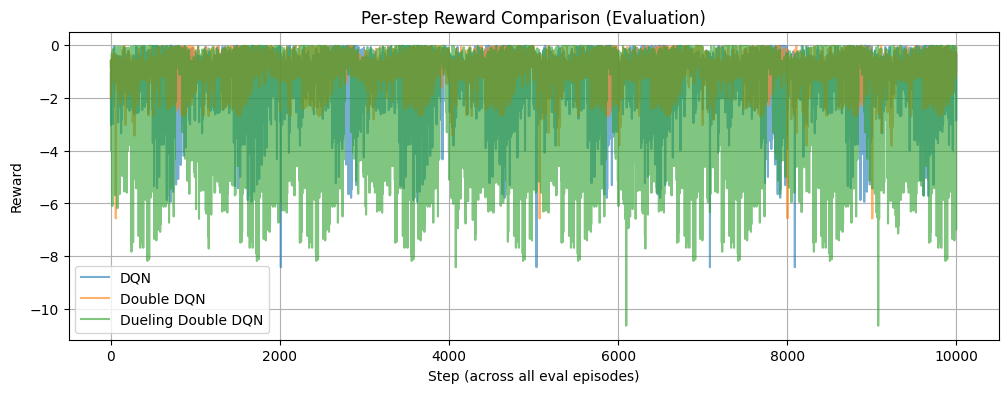

In [9]:
plt.figure()
plt.plot(dqn_df["reward"].reset_index(drop=True), label="DQN", alpha=0.6)
plt.plot(double_df["reward"].reset_index(drop=True), label="Double DQN", alpha=0.6)
plt.plot(dueling_df["reward"].reset_index(drop=True), label="Dueling Double DQN", alpha=0.6)
plt.xlabel("Step (across all eval episodes)")
plt.ylabel("Reward")
plt.title("Per-step Reward Comparison (Evaluation)")
plt.legend()
plt.show()


#Plot Capacity vs Demand for Each Model

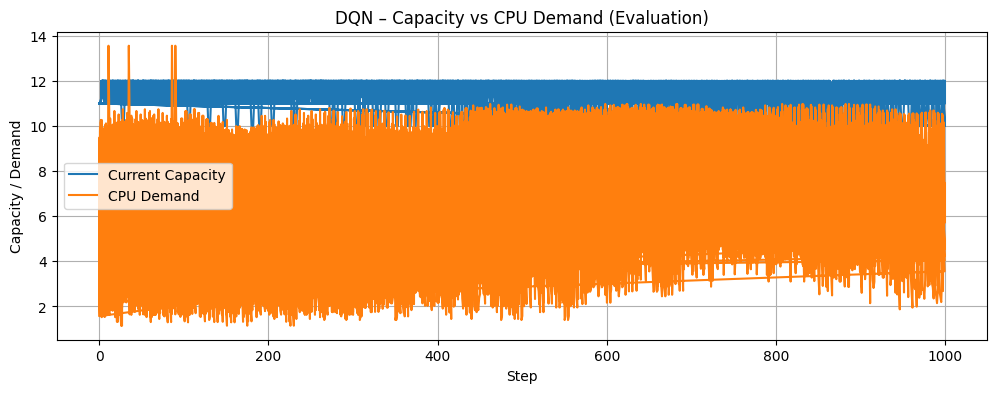

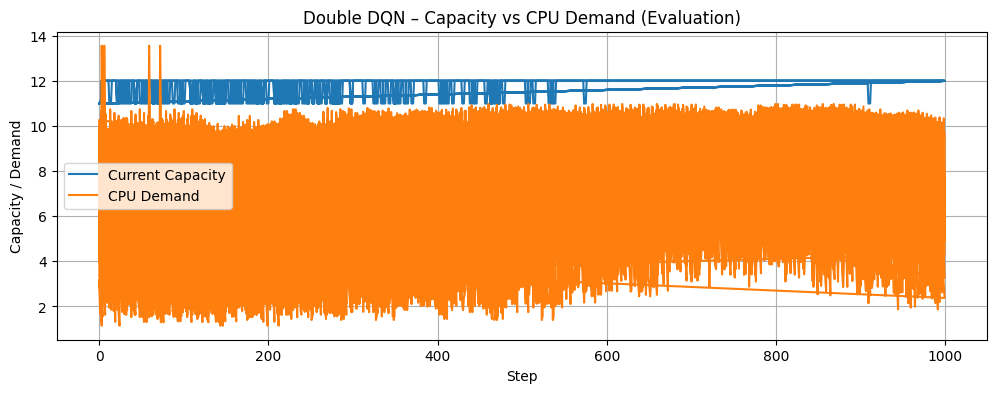

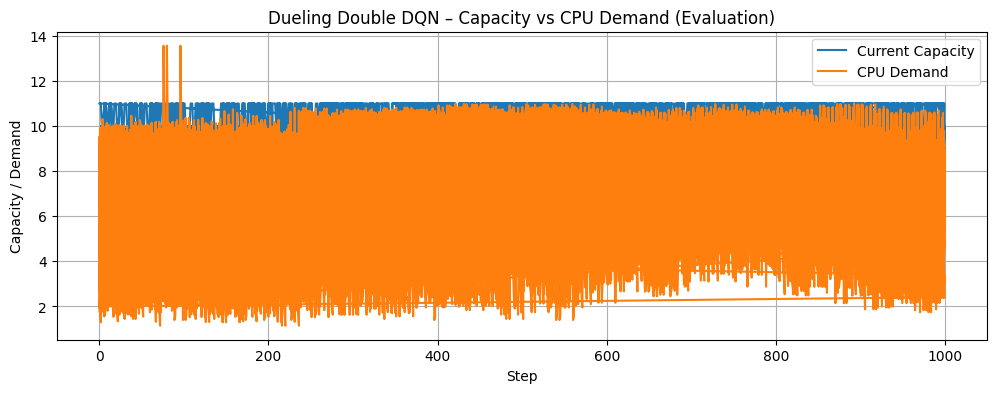

In [10]:
def plot_capacity_vs_demand(df, title):
    plt.figure()
    plt.plot(df.index, df["current_capacity"], label="Current Capacity")
    plt.plot(df.index, df["demand_cpu"], label="CPU Demand")
    plt.xlabel("Step")
    plt.ylabel("Capacity / Demand")
    plt.title(title)
    plt.legend()
    plt.show()

plot_capacity_vs_demand(dqn_df, "DQN – Capacity vs CPU Demand (Evaluation)")
plot_capacity_vs_demand(double_df, "Double DQN – Capacity vs CPU Demand (Evaluation)")
plot_capacity_vs_demand(dueling_df, "Dueling Double DQN – Capacity vs CPU Demand (Evaluation)")



#Plot Utilzation vs target/SLA for the best model

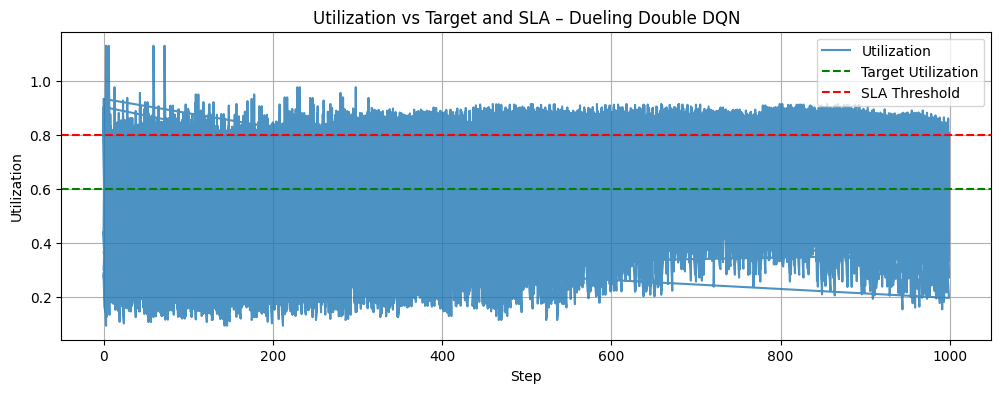

In [11]:
best_df = double_df   # change to dqn_df or double_df if you want to inspect them

plt.figure()
plt.plot(best_df.index, best_df["utilization"], label="Utilization", alpha=0.8)
plt.axhline(env.target_utilization, color="g", linestyle="--", label="Target Utilization")
plt.axhline(env.sla_threshold, color="r", linestyle="--", label="SLA Threshold")
plt.xlabel("Step")
plt.ylabel("Utilization")
plt.title("Utilization vs Target and SLA – Dueling Double DQN")
plt.legend()
plt.show()


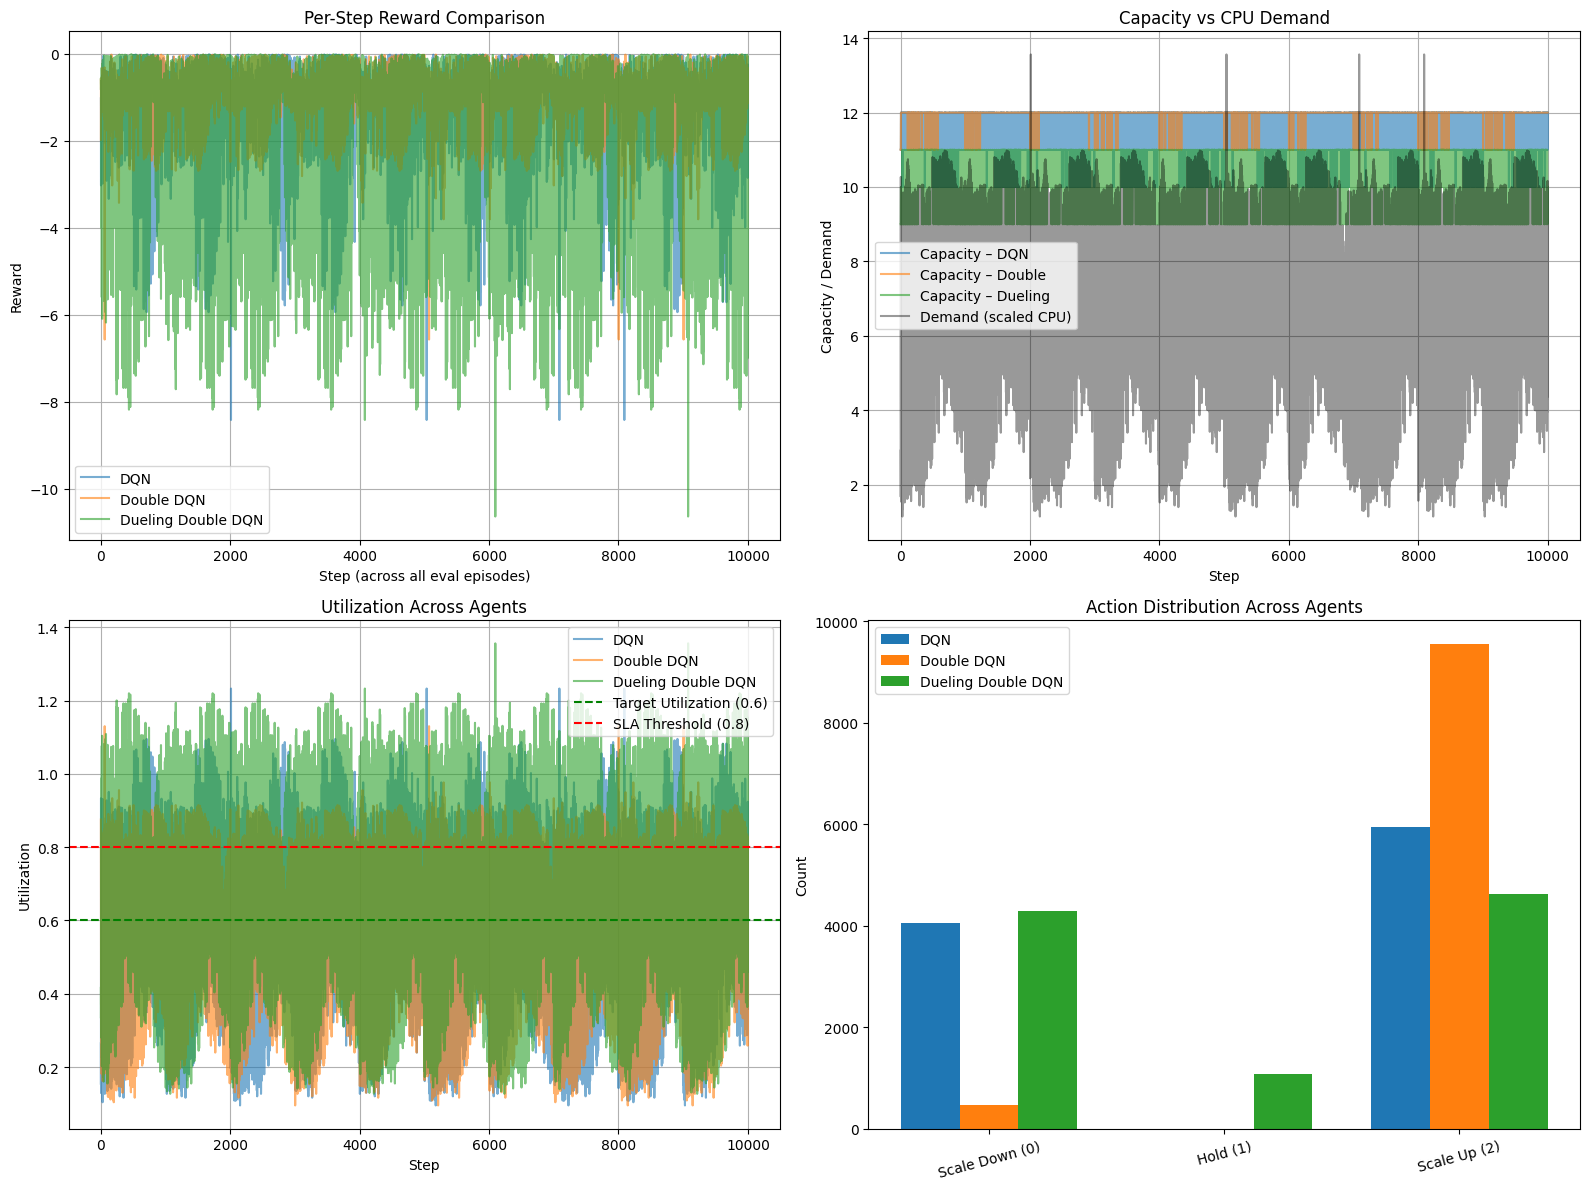

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Reset default figure size
plt.rcParams["figure.figsize"] = (16, 12)

fig, axes = plt.subplots(2, 2)

# -------------------------------------------------------------------------
# 1. REWARD COMPARISON
# -------------------------------------------------------------------------
ax = axes[0, 0]

ax.plot(dqn_df["reward"].reset_index(drop=True),
        label="DQN", alpha=0.6)
ax.plot(double_df["reward"].reset_index(drop=True),
        label="Double DQN", alpha=0.6)
ax.plot(dueling_df["reward"].reset_index(drop=True),
        label="Dueling Double DQN", alpha=0.6)

ax.set_title("Per-Step Reward Comparison")
ax.set_xlabel("Step (across all eval episodes)")
ax.set_ylabel("Reward")
ax.legend()
ax.grid(True)



# -------------------------------------------------------------------------
# 2. CAPACITY VS DEMAND (OVERLAY)
# -------------------------------------------------------------------------
ax = axes[0, 1]

ax.plot(dqn_df["current_capacity"].values, label="Capacity – DQN", alpha=0.6)
ax.plot(double_df["current_capacity"].values, label="Capacity – Double", alpha=0.6)
ax.plot(dueling_df["current_capacity"].values, label="Capacity – Dueling", alpha=0.6)

ax.plot(dqn_df["demand_cpu"].values, label="Demand (scaled CPU)", alpha=0.4, color="black")

ax.set_title("Capacity vs CPU Demand")
ax.set_xlabel("Step")
ax.set_ylabel("Capacity / Demand")
ax.legend()
ax.grid(True)



# -------------------------------------------------------------------------
# 3. UTILIZATION vs TARGET/SLA
# -------------------------------------------------------------------------
ax = axes[1, 0]

ax.plot(dqn_df["utilization"].values, label="DQN", alpha=0.6)
ax.plot(double_df["utilization"].values, label="Double DQN", alpha=0.6)
ax.plot(dueling_df["utilization"].values, label="Dueling Double DQN", alpha=0.6)

ax.axhline(env.target_utilization, linestyle="--", color="green", label="Target Utilization (0.6)")
ax.axhline(env.sla_threshold, linestyle="--", color="red", label="SLA Threshold (0.8)")

ax.set_title("Utilization Across Agents")
ax.set_xlabel("Step")
ax.set_ylabel("Utilization")
ax.legend()
ax.grid(True)



# -------------------------------------------------------------------------
# 4. ACTION DISTRIBUTION (BAR CHART)
# -------------------------------------------------------------------------
ax = axes[1, 1]

def action_summary(df):
    return np.array([
        (df["action"] == 0).sum(),
        (df["action"] == 1).sum(),
        (df["action"] == 2).sum()
    ])

dqn_actions = action_summary(dqn_df)
double_actions = action_summary(double_df)
dueling_actions = action_summary(dueling_df)

x = np.arange(3)
width = 0.25

ax.bar(x - width, dqn_actions, width, label="DQN")
ax.bar(x,         double_actions, width, label="Double DQN")
ax.bar(x + width, dueling_actions, width, label="Dueling Double DQN")

ax.set_xticks(x)
ax.set_xticklabels(["Scale Down (0)", "Hold (1)", "Scale Up (2)"], rotation=15)
ax.set_title("Action Distribution Across Agents")
ax.set_ylabel("Count")
ax.legend()
ax.grid(False)



# -------------------------------------------------------------------------
# FINAL LAYOUT
# -------------------------------------------------------------------------
plt.tight_layout()
plt.show()


# Results and Discussion

To compare the performance of the three Q-learning–based algorithms—**DQN**, **Double DQN**, and **Dueling Double DQN**—each agent was evaluated on **ten 1,000-step episodes** using the same environment configuration and workload windows. The table below summarizes the key performance metrics.

| Model                | Mean Reward | Reward Std | Mean Capacity | SLA Violations |
|----------------------|------------:|-----------:|--------------:|---------------:|
| **DQN**              | –936.56     | 43.57      | 11.38         | 1705           |
| **Double DQN**       | –836.43     | 58.47      | 11.95         | 1542           |
| **Dueling Double DQN** | –1253.79  | 98.51      | 9.91          | 2019           |

The results show that **vanilla DQN performs poorly** on this autoscaling task, exhibiting a lower mean reward and a high number of SLA violations (1705). This behavior is consistent with known issues of **Q-value overestimation bias** in DQN, which can lead to unstable learning and suboptimal action selection in environments requiring a careful balance of cost and SLA penalties.

In contrast, **Double DQN achieves the best performance** among the three, with the highest mean reward (–836.43) and the fewest SLA violations (1542), although this is still a substantial number. By decoupling action selection and action evaluation, Double DQN reduces Q-value overestimation and learns a more stable and generally better-performing scaling policy than vanilla DQN.

The **Dueling Double DQN** agent performed the **worst** in this evaluation, with the lowest mean reward (–1253.79) and the highest SLA violations (2019). Although the dueling network architecture is intended to improve value estimation by separating state-value and advantage computations, in this particular environment it did not translate into superior performance. In fact, it significantly underperformed both DQN and Double DQN.

Overall, these experiments demonstrate that **Double DQN provides the best balance of cost efficiency and SLA reliability** among the three methods in this evaluation. These findings highlight the importance of **bias-corrected Q-learning methods** for reinforcement learning in cloud autoscaling scenarios, even though absolute performance across all models was lower in this evaluation run.

